In [ ]:
%matplotlib inline

import zipline
from zipline.api import order_target_percent, symbol,  \
    set_commission, set_slippage, schedule_function, \
    date_rules, time_rules, attach_pipeline, pipeline_output, set_benchmark
from pandas import Timestamp
import matplotlib.pyplot as plt
import pyfolio as pf
import pandas as pd
import numpy as np  
from scipy import stats  
from zipline.finance.commission import PerDollar
from zipline.finance.slippage import VolumeShareSlippage, FixedSlippage
from zipline_norgatedata.pipelines import NorgateDataIndexConstituent
from zipline.pipeline import Pipeline
import norgatedata

'''

Prior to running this, create a new bundle in extension.py:

from zipline_norgatedata import register_norgatedata_equities_bundle

register_norgatedata_equities_bundle(
    bundlename = 'norgatedata-sp500',
    symbol_list = ['$SPXTR'],
    watchlists = ['S&P 500 Current & Past'],
    start_session = '1990-01-02',
)
    
and also run:

zipline ingest -b norgatedata-sp500

'''

"""
Model Settings
"""
intial_portfolio = 100000
momentum_window1 = 125
momentum_window2 = 125
minimum_momentum = 40
portfolio_size = 30
vola_window = 20

# Trend filter settings
enable_trend_filter = False
trend_filter_symbol = '$SPXTR'
trend_filter_window = 200

"""
Commission and Slippage Settings
"""
enable_commission = True
commission_pct = 0.001
enable_slippage = True 
slippage_volume_limit = 0.025
slippage_impact = 0.05

"""
Helper functions.
"""

def momentum_score(ts):
    """
    Input:  Price time series.
    Output: Annualized exponential regression slope, 
            multiplied by the R2
    """
    # Make a list of consecutive numbers
    x = np.arange(len(ts)) 
    # Get logs
    log_ts = np.log(ts) 
    # Calculate regression values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, log_ts)
    # Annualize percent
    annualized_slope = (np.power(np.exp(slope), 252) - 1) * 100
    #Adjust for fitness
    score = annualized_slope * (r_value ** 2)
    return score

def volatility(ts):
    return ts.pct_change().rolling(vola_window).std().iloc[-1]

"""
Initialization and trading logic
"""

def make_pipeline():
   indexconstituent = NorgateDataIndexConstituent('$SPX')
   return Pipeline(
       columns={
            'NorgateDataIndexConstituent':indexconstituent},
       screen = indexconstituent)

def initialize(context):
    set_benchmark(symbol('$SPXTR'))    
    attach_pipeline(make_pipeline(), 'norgatedata_pipeline', chunks=9999,eager=True)

    # Set commission and slippage.
    if enable_commission:
        comm_model = PerDollar(cost=commission_pct)
    else:
        comm_model = PerDollar(cost=0.0)
    set_commission(comm_model)
    
    if enable_slippage:
        slippage_model=VolumeShareSlippage(volume_limit=slippage_volume_limit, price_impact=slippage_impact)
        set_slippage(slippage_model)
    else:
        slippage_model=FixedSlippage(spread=0.0)        
    
    # Used only for progress output.
    context.last_month = intial_portfolio
    
    # Store index membership
    #context.index_members = pd.read_csv('../data/index_members/sp500.csv', index_col=0, parse_dates=[0])
    
    #Schedule rebalance monthly.
    schedule_function(
        func=rebalance,
        date_rule=date_rules.month_start(),
        time_rule=time_rules.market_open()
    )
    
def output_progress(context):
    """
    Output some performance numbers during backtest run
    """
    
    # Get today's date
    today = zipline.api.get_datetime().date()
    
    # Calculate percent difference since last month
    perf_pct = (context.portfolio.portfolio_value / context.last_month) - 1
    
    # Print performance, format as percent with two decimals.
    print("{} - Last Month Result: {:.2%}".format(today, perf_pct))
    
    # Remember today's portfolio value for next month's calculation
    context.last_month = context.portfolio.portfolio_value
       
    
def rebalance(context, data):
    # Write some progress output during the backtest
    output_progress(context)
    context.pipeline_data = pipeline_output('norgatedata_pipeline')
    
    todays_universe = context.pipeline_data.index
   

    # Check how long history window we need.
    hist_window = max(momentum_window1,
                      momentum_window2) 
    
    # Get historical data
    hist = data.history(todays_universe, "close", hist_window, "1d")
    
    # Slice the history to match the two chosen time frames.
    momentum_hist1 = hist[(-1 * momentum_window1):]
    momentum_hist2 = hist[(-1 * momentum_window2):]
    
    # Calculate momentum values for the two time frames.
    momentum_list1 = momentum_hist1.apply(momentum_score)  
    momentum_list2 = momentum_hist2.apply(momentum_score) 
    
    # Now let's put the two momentum values together, and calculate mean.
    momentum_concat = pd.concat((momentum_list1, momentum_list2))
    mom_by_row = momentum_concat.groupby(momentum_concat.index)
    mom_means = mom_by_row.mean()
    
    # Sort by momentum value.
    ranking_table = mom_means.sort_values(ascending=False)

    """
    Sell Logic
    
    First we check if any existing position should be sold.
    * Sell if stock is no longer part of index.
    * Sell if stock has too low momentum value.
    """
    kept_positions = list(context.portfolio.positions.keys())
    for security in context.portfolio.positions:
        if (security not in todays_universe):
            order_target_percent(security, 0.0)
            kept_positions.remove(security)          
        elif ranking_table[security] < minimum_momentum:
            order_target_percent(security, 0.0)
            kept_positions.remove(security)         
    
    """
    Trend Filter Section
    """
    if enable_trend_filter:
        ind_hist = data.history(
            symbol(trend_filter_symbol), 
            'close', 
            trend_filter_window, 
            '1d'
        )
        
        trend_filter = ind_hist.iloc[-1] > ind_hist.mean()    
        if trend_filter == False:
            return    
    
    """
    Stock Selection Logic
    
    Check how many stocks we are keeping from last month.
    Fill from top of ranking list, until we reach the
    desired total number of portfolio holdings.
    """
    replacement_stocks = portfolio_size - len(kept_positions)
    buy_list = ranking_table.loc[
        ~ranking_table.index.isin(kept_positions)][:replacement_stocks]
    
    new_portfolio = pd.concat(
        (buy_list, 
         ranking_table.loc[ranking_table.index.isin(kept_positions)])
    )
    

    """
    Calculate inverse volatility for stocks, 
    and make target position weights.
    """
    vola_table = hist[new_portfolio.index].apply(volatility)
    inv_vola_table = 1 / vola_table 
    sum_inv_vola = np.sum(inv_vola_table)         
    vola_target_weights = inv_vola_table / sum_inv_vola
    
    for security, rank in new_portfolio.items():
        weight = vola_target_weights[security]
        if weight != weight: # This will happen with volatiltiy=0 and then weight becomes infinite (NaN)
            weight = 0 # Stay out of a zero volatility position - the security is probably flatlining
        if security in kept_positions:
            order_target_percent(security, weight)
        else:
            if ranking_table[security] > minimum_momentum:
                order_target_percent(security, weight)

def analyze(context, perf):
    
    perf['max'] = perf.portfolio_value.cummax()
    perf['dd'] = (perf.portfolio_value / perf['max']) - 1
    maxdd = perf['dd'].min()
    
    ann_ret = (np.power((perf.portfolio_value.iloc[-1] / perf.portfolio_value.iloc[0]),(252 / len(perf)))) - 1
    
    print("Annualized Return: {:.2%} Max Drawdown: {:.2%}".format(ann_ret, maxdd))

    return   
        
start_date = Timestamp('1997-01-01')
end_date = Timestamp('2024-08-29')

# Turn off all warnings to make the output nicer:
import warnings
warnings.filterwarnings("ignore")

perf = zipline.run_algorithm(
    start=start_date, end=end_date, 
    initialize=initialize, 
    analyze=analyze, 
    capital_base=intial_portfolio,  
    data_frequency = 'daily', 
    bundle='norgatedata-sp500' ) 



[2024-09-27 01:10:16.479560] INFO: Norgate Data: NorgateData package v1.0.74: Init complete
[2024-09-27 01:10:16.482212] INFO: Norgate Data: Zipline v3.1 detected
[2024-09-27 01:10:16.482936] INFO: Norgate Data: Zipline_norgatedata package v3.1.0: Init complete
[2024-09-27 01:10:27.924142] INFO: Norgate Data: Populating NorgateDataIndexConstituent pipeline populating with $SPX on 1239 securities from 1997-01-02 to 2024-08-29....
[2024-09-27 01:10:43.100972] INFO: Norgate Data: Pipeline NorgateDataIndexConstituent with $SPX: Done
1997-01-02 - Last Month Result: 0.00%
1997-02-03 - Last Month Result: 7.86%
1997-03-03 - Last Month Result: 0.19%
1997-04-01 - Last Month Result: -3.91%
1997-05-01 - Last Month Result: 5.15%
1997-06-02 - Last Month Result: 5.48%
1997-07-01 - Last Month Result: 4.98%


Cannot place order for GWF-199707, as it has de-listed. Any existing positions for this asset will be liquidated on 1997-06-30 00:00:00.


1997-08-01 - Last Month Result: 9.35%
1997-09-02 - Last Month Result: 2.90%
1997-10-01 - Last Month Result: 4.26%
1997-11-03 - Last Month Result: -5.79%
1997-12-01 - Last Month Result: -2.06%
1998-01-02 - Last Month Result: -0.71%
1998-02-02 - Last Month Result: 0.28%
1998-03-02 - Last Month Result: 3.12%
1998-04-01 - Last Month Result: 5.80%
1998-05-01 - Last Month Result: 1.90%
1998-06-01 - Last Month Result: -2.55%
1998-07-01 - Last Month Result: 10.02%
1998-08-03 - Last Month Result: -0.64%
1998-09-01 - Last Month Result: -8.81%
1998-10-01 - Last Month Result: -0.44%


Cannot place order for USS-199810, as it has de-listed. Any existing positions for this asset will be liquidated on 1998-09-30 00:00:00.


1998-11-02 - Last Month Result: 5.69%
1998-12-01 - Last Month Result: 1.92%
1999-01-04 - Last Month Result: 3.85%
1999-02-01 - Last Month Result: 2.80%
1999-03-01 - Last Month Result: -3.28%
1999-04-01 - Last Month Result: 6.81%
1999-05-03 - Last Month Result: 0.47%
1999-06-01 - Last Month Result: -2.01%
1999-07-01 - Last Month Result: 10.38%
1999-08-02 - Last Month Result: -2.39%
1999-09-01 - Last Month Result: 0.92%
1999-10-01 - Last Month Result: -2.11%
1999-11-01 - Last Month Result: 0.90%
1999-12-01 - Last Month Result: 14.31%
2000-01-03 - Last Month Result: 15.38%
2000-02-01 - Last Month Result: -2.19%
2000-03-01 - Last Month Result: 24.49%
2000-04-03 - Last Month Result: -4.30%
2000-05-01 - Last Month Result: 1.68%
2000-06-01 - Last Month Result: -3.41%
2000-07-03 - Last Month Result: 8.58%
2000-08-01 - Last Month Result: -6.79%
2000-09-01 - Last Month Result: 3.67%
2000-10-02 - Last Month Result: 2.32%
2000-11-01 - Last Month Result: 0.67%
2000-12-01 - Last Month Result: -2.82%

Cannot place order for CIT.A-200106, as it has de-listed. Any existing positions for this asset will be liquidated on 2001-05-31 00:00:00.


2001-07-02 - Last Month Result: -0.13%
2001-08-01 - Last Month Result: -1.08%
2001-09-04 - Last Month Result: -2.63%
2001-10-01 - Last Month Result: -10.71%
2001-11-01 - Last Month Result: -0.08%
2001-12-03 - Last Month Result: 2.32%
2002-01-02 - Last Month Result: 0.33%
2002-02-01 - Last Month Result: -0.51%
2002-03-01 - Last Month Result: 3.44%
2002-04-01 - Last Month Result: -0.24%
2002-05-01 - Last Month Result: 0.58%
2002-06-03 - Last Month Result: -2.51%
2002-07-01 - Last Month Result: -2.42%
2002-08-01 - Last Month Result: -11.88%
2002-09-03 - Last Month Result: -2.09%
2002-10-01 - Last Month Result: 0.37%
2002-11-01 - Last Month Result: 0.59%
2002-12-02 - Last Month Result: 0.55%
2003-01-02 - Last Month Result: -0.19%
2003-02-03 - Last Month Result: -6.16%
2003-03-03 - Last Month Result: -2.21%
2003-04-01 - Last Month Result: 1.98%
2003-05-01 - Last Month Result: 13.35%
2003-06-02 - Last Month Result: 10.86%
2003-07-01 - Last Month Result: 3.08%
2003-08-01 - Last Month Result: 

Start date,1997-01-03
End date,2024-08-29
Total months,331
,Backtest
Annual return,11.32%
Cumulative returns,1833.422%
Annual volatility,18.964%
Sharpe ratio,0.66
Calmar ratio,0.29
Stability,0.96
Max drawdown,-39.11%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,39.11,2007-11-06,2009-05-13,2010-04-15,638
1,34.74,2001-05-21,2003-03-11,2003-10-07,622
2,34.35,2018-09-04,2020-03-18,2021-02-08,635
3,26.36,2000-04-07,2000-04-14,2000-12-28,190
4,18.60,1998-07-20,1998-08-31,1999-03-18,174


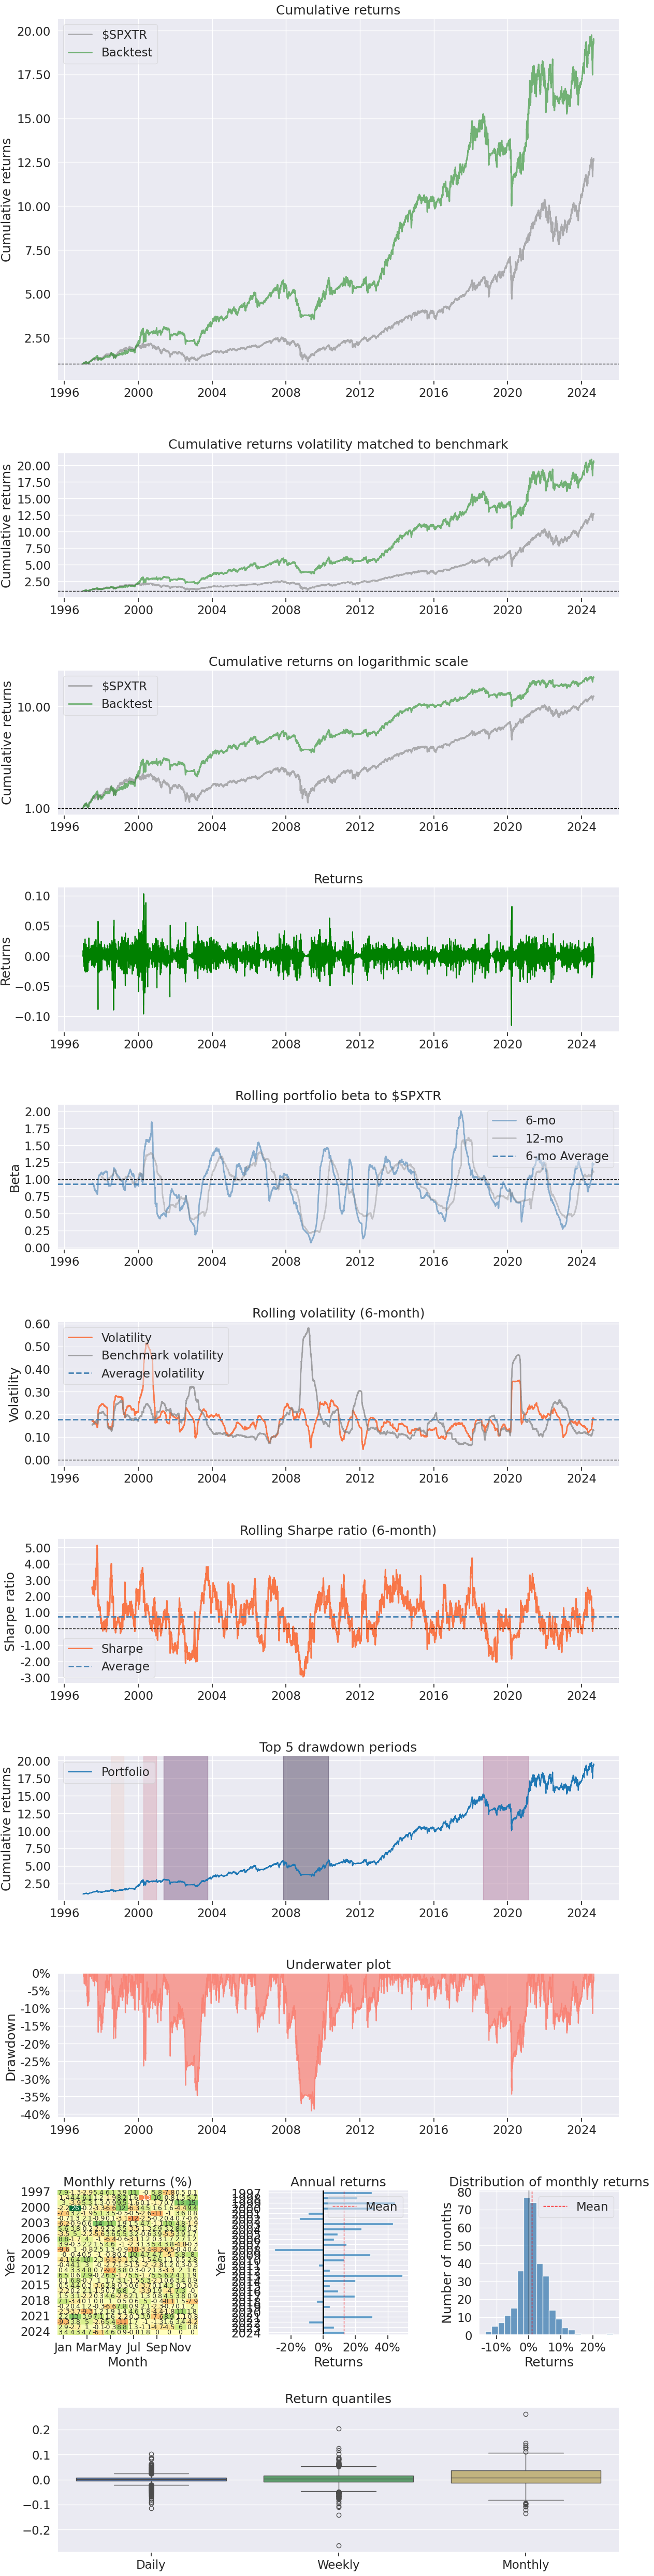

In [2]:
# The following supresses all warnings - mainly because there is some code within pyfolio, 
# empyrical, pandas and matplotlib that has deprecated calls - this just supresses the
# warnings from showing
import warnings
warnings.filterwarnings('ignore')

returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf)
spxtr = norgatedata.price_timeseries(
    '$SPXTR',
    start_date = returns.index[0],
    end_date = returns.index[-1],
    format='pandas-dataframe',
    timezone='UTC',
)
spxtr_rets = spxtr['Close'].pct_change().dropna()
spxtr_rets.name = '$SPXTR'
pf.create_returns_tear_sheet(returns, benchmark_rets=spxtr_rets)

In [3]:
perf.portfolio_value.to_csv('../Backtests/equity_momentum.csv')